In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.gridspec as gridspec

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

### Residuals Comparison

In [80]:
exop_folder = '../exop_hosts/'
age_pred = pd.read_csv(exop_folder + 'exop_host_ages-v1/age_predictions.csv')
archive_ages = pd.read_csv(exop_folder + 'archive_ages_default.csv')

In [110]:
age_pred['pred_median_myr'] = 10**age_pred['pred_median']
age_pred['pred_p16_myr'] = 10**age_pred['pred_p16']
age_pred['pred_p84_myr'] = 10**age_pred['pred_p84']
age_pred['1sigma'] = (age_pred['pred_p84'] - age_pred['pred_p16']) / 2
age_pred['1sigma_upper'] = age_pred['pred_p84'] - age_pred['pred_median']
age_pred['1sigma_lower'] = age_pred['pred_median'] - age_pred['pred_p16']
age_pred['1sigma_upper_myr'] = age_pred['pred_p84_myr'] - age_pred['pred_median_myr']
age_pred['1sigma_lower_myr'] = age_pred['pred_median_myr'] - age_pred['pred_p16_myr']
age_pred['1sigma_myr'] = (age_pred['1sigma_upper_myr'] + age_pred['1sigma_lower_myr']) / 2

In [111]:
archive_ages['logA_Myr'] = np.log10(archive_ages['st_age'] * 1e3)
archive_ages['logA_Myr_err'] = (np.log10(archive_ages['st_age'] + archive_ages['st_ageerr1']) - np.log10((archive_ages['st_age'] + archive_ages['st_ageerr2']).clip(lower=0.00001)))/2
archive_ages['st_err'] = (archive_ages['st_ageerr1'] + archive_ages['st_ageerr2']) / 2


In [112]:
def combine_group(g):
    mean_logA = g['logA_Myr'].mean()
    mean_ageGyr = g['st_age'].mean()
    mean_err_sq = (g['logA_Myr_err'] ** 2).mean()
    mean_err_ageGyr_sq = (g['st_err'] ** 2).mean()
    spread_sq = g['logA_Myr'].std(ddof=0) ** 2  # ddof=0: population std since we want the scatter, not SE
    combined_err = np.sqrt(mean_err_sq + spread_sq)
    return pd.Series({
        'logA_Myr': mean_logA,
        'logA_Myr_err': combined_err,
        'st_age': mean_ageGyr,
        'st_err': np.sqrt(mean_err_ageGyr_sq + (g['st_age'].std(ddof=0) ** 2)),
        'n_estimates': len(g),
    })

archive_ages_grouped = (
    archive_ages
    .groupby('GaiaDR3_ID', as_index=True)
    .apply(combine_group)
    .reset_index()
)


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_50775/3518911051.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_group)


In [113]:
joined = age_pred.merge(archive_ages_grouped, left_on='gaia_id', right_on='GaiaDR3_ID', how='inner')

In [114]:
joined

,gaia_id,bprp0,pred_median,pred_mean,pred_map,pred_p16,pred_p84,pred_median_myr,1sigma,1sigma_upper,...,pred_p84_myr,1sigma_upper_myr,1sigma_lower_myr,1sigma_myr,GaiaDR3_ID,logA_Myr,logA_Myr_err,st_age,st_err,n_estimates
0,1003351437484254464,1.482303,2.038919,2.072871,2.043063,1.765405,2.353874,109.375235,0.294234,0.314955,...,225.878034,116.502799,51.110551,83.806675,1003351437484254464,4.059942,0.147141,11.48,1.370,1.0
1,1008018211509401728,1.168413,1.910451,1.969500,1.707387,1.603784,2.407748,81.367411,0.401982,0.497297,...,255.709993,174.342581,41.208337,107.775459,1008018211509401728,3.130334,0.058253,1.35,0.000,1.0
2,101040381244467968,1.172968,2.059640,2.050911,2.121802,1.773694,2.329009,114.720148,0.277658,0.269369,...,213.308912,98.588763,55.332832,76.960798,101040381244467968,2.838849,0.129597,0.69,0.000,1.0
3,1011435012611767552,0.736625,2.125946,1.864872,2.747568,0.368829,2.789009,133.642934,1.210090,0.663063,...,615.189621,481.546688,131.305018,306.425853,1011435012611767552,3.491362,0.110924,3.10,0.100,1.0
4,1022456104850892928,1.846450,0.169910,0.312740,0.000000,0.045586,0.489009,1.478802,0.221712,0.319099,...,3.083252,1.604450,0.368130,0.986290,1022456104850892928,3.602060,0.422549,4.00,0.000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2241,94468978202180352,0.858776,3.833333,3.538645,4.140000,3.352613,4.052973,6812.920168,0.350180,0.219640,...,11297.256777,4484.336609,4560.691407,4522.514008,94468978202180352,3.748188,0.183074,5.60,0.050,1.0
2242,959971546241608576,0.714700,1.230811,1.164870,1.251532,1.027748,1.342703,17.014171,0.157477,0.111892,...,22.014189,5.000018,6.354402,5.677210,959971546241608576,3.378398,0.067779,2.39,0.000,1.0
2243,978086481343568128,2.095446,2.474054,2.478574,2.469910,2.266847,2.681261,297.888680,0.207207,0.207207,...,480.022175,182.133495,113.026956,147.580225,978086481343568128,3.850033,0.145126,7.08,0.445,1.0
2244,995754258812449024,0.722149,2.706126,2.759259,2.635676,2.465766,3.124685,508.307128,0.329459,0.418558,...,1332.553333,824.246205,216.049605,520.147905,995754258812449024,3.505150,0.068419,3.20,0.000,1.0


### Age prediction histogram

In [71]:
np.mean(age_pred['1sigma'])

0.44686847900088655

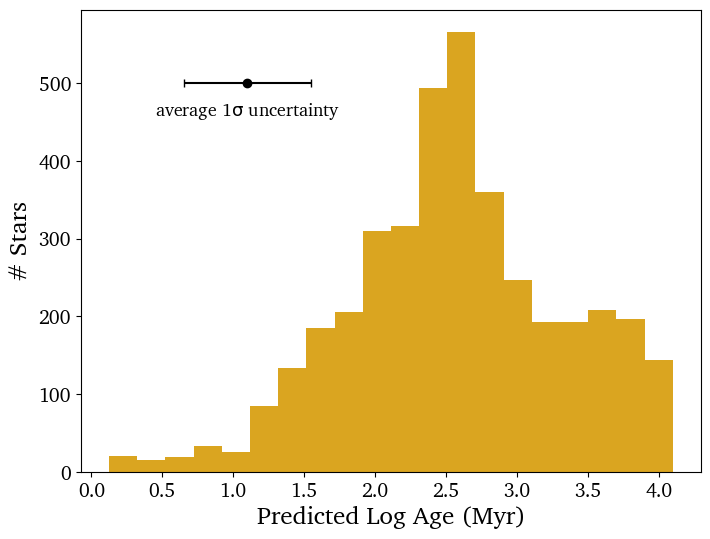

In [142]:
fig = plt.figure(figsize=(8,6))
plt.hist(age_pred['pred_median'], bins=20, alpha=1, label='Median estimate',color='goldenrod')
# plt.hist(age_pred['pred_map'], bins=20, alpha=0.5, label='MAP Estimate')
plt.errorbar(1.1,500,xerr=np.mean(age_pred['1sigma']), fmt='o', color='black', label='Average 1-sigma uncertainty',capsize=3)
plt.text(1.1, 450, r'average 1$\rm \sigma$ uncertainty', ha='center', va='bottom',fontsize=13)
plt.xlabel('Predicted Log Age (Myr)',fontsize=18)
plt.ylabel('# Stars',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend()
plt.show()

### Comparison of lit age estimates

In [124]:
med_xerr = np.mean(joined['logA_Myr_err'])
med_yerr = np.mean(joined['1sigma'])

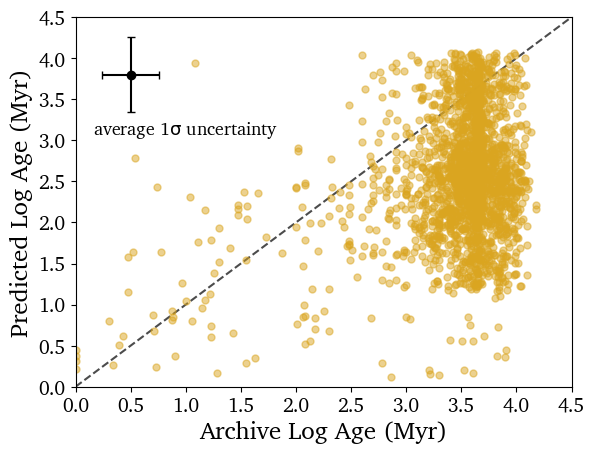

In [138]:
plt.errorbar(joined['logA_Myr'], joined['pred_median'],
             xerr=joined['logA_Myr_err'], yerr=[joined['1sigma_lower'], joined['1sigma_upper']], fmt='o', alpha=0.5,
             markersize=5,elinewidth=0, capsize=0,color='goldenrod')
plt.errorbar(0.5,3.8, xerr=med_xerr, yerr=med_yerr, fmt='o', color='black', label='Average 1-sigma uncertainty',capsize=3)
plt.text(1, 3, r'average 1$\rm \sigma$ uncertainty', ha='center', va='bottom',fontsize=13)
plt.xlabel('Archive Log Age (Myr)',fontsize=18)
plt.ylabel('Predicted Log Age (Myr)',fontsize=18)
plt.plot([0,5], [0,5], 'k--', alpha=0.7)
plt.xlim(0,4.5)
plt.ylim(0,4.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

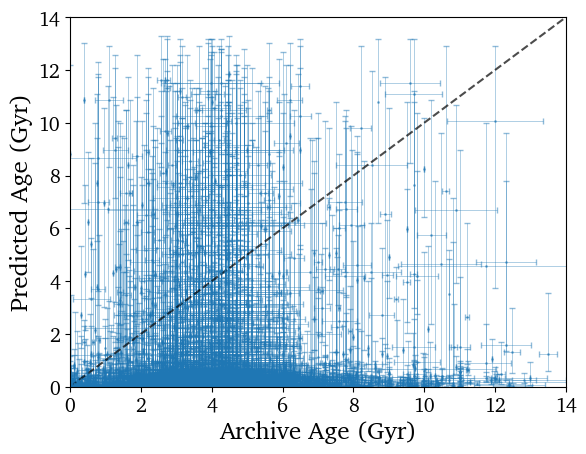

In [119]:
plt.errorbar(joined['st_age'], joined['pred_median_myr']/1000, xerr=joined['st_err'],
             yerr=[joined['1sigma_lower_myr']/1000, joined['1sigma_upper_myr']/1000], fmt='o', alpha=0.5,
             markersize=1,elinewidth=0.5, capsize=2)
plt.xlabel('Archive Age (Gyr)',fontsize=18)
plt.ylabel('Predicted Age (Gyr)',fontsize=18)
plt.plot([0,14], [0,14], 'k--', alpha=0.7)
plt.xlim(0,14)
plt.ylim(0,14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()